# 18d — Refugia transform conditionality (E20 / PF-1): the zero-solve audit and the test layer

Study plan v0.18, post-freeze register PF-1 (a disclosed sensitivity; never an amendment to the registered design). Question: how much
of the curated core (82% densest refugia) is the `1/v` transform's doing? The reciprocal is orientation PLUS convexity — it restored
the contrast lost to the additive flip and manufactured a steep tail (leverage 0.090 → 0.422; the ≥5× tail on 0.48% of the region).

**Extended 2026-09-16 (spec v0.18 PF-2, M4.35): the uniform value-shape audit** — every continuous value under its defensible shapes, the precision-relative contrast test (PF-1 correction: rank is a construction check, not a realness test), the consistent-set layers and weights for a second guarded run (18f).

Two separable questions, pre-registered in methods_log M4.34 before any solve:
1. **Numerics** — is the tail top a v → 0 artifact? Velocity floor at the data's grain: one cell width (1 km) over the elapsed span
   (1961–1990 → 2071–2100 midpoints = 110 yr) → v_floor = 1/110 km/yr. Precedent: dust thresholding.
2. **Value model** — value is not obviously linear in residence time. Variants audited: rank (reference only, inadmissible as a feature),
   floored `1/max(v, v_floor)`, `log1p(1/v)` (the saturating model, R1's concave candidate), horizon-capped `min(1/v, H)` with
   H = planning horizon (2100 − 2025 = 75 yr) over a 10 km habitat span → 7.5 yr/km, plus a cap ladder for context.

Products: `spec/v3.1/E20_refugia_audit.csv` (leverage, class, θ-tail, top-30% Jaccard, where the core sits, per variant × realization),
the test layers `input_data/aligned_stack/e20_log_refugia_{585,245}.tif`, and `spec/v3.1/e20_refugia_transform.json` (the guarded run's
weights under constant intended influence, its targets, expectations). Then **18e** (R, Ethan: one guarded run, S0@SSP585 under
`log1p(1/v)`, ~1 h) → **18g** (the transform-conditional share of the core).

In [1]:
# ---- bootstrap ----------------------------------------------------------------------------------------------
import importlib, json, pathlib, sys
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.py").exists()]
ROOT = _cands[0]; sys.path.insert(0, str(ROOT))
import config, leverage_core as lc, ensemble_core as ec, director_core as dc
for _m in (config, lc, ec, dc):
    importlib.reload(_m)
VP = dc.VP; assert VP.version == "v3.1", "E20 is a post-freeze sensitivity on the v3.1 record (study plan v0.18 PF-1)"
G = dc.grid(); RUNS, REC, SPEC = dc.RUNS, dc.SPEC_REC, dc.SPEC
FIG = ROOT / "analyses" / "y2y" / "figures" / VP.version; FIG.mkdir(exist_ok=True, parents=True)
PKG = dc.PKG
RAW = {lv: lc._read(ROOT / "input_data" / "cleaned_aligned" / "climate_scenarios" / f"{lv}_2071_2100.tif")[G.pu] for lv in ("585", "245")}
STACK = {"585": lc._read(config.HANDOFF_DIR / "climate_type_macrorefugia.tif")[G.pu],
         "245": lc._read(config.HANDOFF_DIR / "climate_realizations" / "macrorefugia_245_2071_2100.tif")[G.pu]}
for lv in RAW:
    assert np.isfinite(RAW[lv]).all() and (RAW[lv] > 0).all(), f"{lv}: raw velocity has non-finite or non-positive cells on the PU"
    assert np.nanmax(np.abs(1.0 / RAW[lv] - STACK[lv])) < 1e-6, f"{lv}: the stack layer is not 1/v of the raw realization"
SPAN_YR = 110.0                      # 1961-1990 -> 2071-2100, midpoint to midpoint
V_FLOOR = 1.0 / SPAN_YR              # one cell width (1 km) over the span, km/yr
HORIZON_YR, SPAN_KM = 75.0, 10.0     # planning horizon to 2100 over a 10 km habitat span
CAP = HORIZON_YR / SPAN_KM           # yr/km
CAP_LADDER = (1.5, 2.0, 3.0, 5.0, CAP)
print(f"VERSION {VP.version} | PU {G.n_pu:,} | v_floor {V_FLOOR:.4f} km/yr (min v on PU {min(RAW[lv].min() for lv in RAW):.4f}) | cap {CAP:.1f} yr/km")


VERSION v3.1 | PU 1,272,914 | v_floor 0.0091 km/yr (min v on PU 0.0433) | cap 7.5 yr/km


In [2]:
# ---- the variants and the audit battery (per realization) ----------------------------------------------------------
def variants(v):
    r = 1.0 / v
    out = {"1/v (registered)": r,
           "floored 1/max(v, v_floor)": 1.0 / np.maximum(v, V_FLOOR),
           "log1p(1/v)": np.log1p(r),
           f"capped min(1/v, {CAP:.1f})": np.minimum(r, CAP)}
    for c in CAP_LADDER[:-1]:
        out[f"capped min(1/v, {c:.1f})"] = np.minimum(r, c)
    out["rank (CONSTRUCTION CHECK: any layer ranked has this leverage -- not a realness test, PF-1 correction)"] = pd.Series(r).rank(pct=True).to_numpy()
    return out
theta = config.AUDIT["theta"]; k30 = int(round(0.30 * G.n_disc))
CORE = dc.to_grid(G, np.zeros(G.n_pu, bool), fill=False, dtype=bool)
with rasterio.open(PKG / "geotiffs" / "act_tiers_guarded.tif") as s:
    core1d = (s.read(1)[G.pu] == 3)
rows = []
for lv in ("585", "245"):
    V = variants(RAW[lv]); ref = V["1/v (registered)"]
    ref_top = np.zeros(G.n_pu, bool); ref_top[G.disc] = ref[G.disc] >= np.sort(ref[G.disc])[-k30]
    for name, x in V.items():
        cls, lever, target, d = lc.classify_values(x[G.disc], config.AUDIT)
        m = float(x[G.disc].mean()); tail = x[G.disc] >= theta * m
        top = np.zeros(G.n_pu, bool); top[G.disc] = x[G.disc] >= np.sort(x[G.disc])[-k30]
        pct = pd.Series(x[G.disc]).rank(pct=True).to_numpy()
        core_pct = float(np.mean(pct[core1d[G.disc]]))
        rows.append(dict(realization=f"ssp{lv}", variant=name, leverage=d["leverage"], cap_min=d["cap_min"], cap_max=d["cap_max"], cls=cls,
                         theta_tail_area_pct=100 * float(tail.mean()), theta_tail_mass=float(x[G.disc][tail].sum() / x[G.disc].sum()),
                         gini=float(lc._gini(x[G.disc])), top30_jaccard_vs_registered=float((top & ref_top).sum() / (top | ref_top).sum()),
                         core_mean_percentile=core_pct, core_in_top30_pct=100 * float(top[core1d].mean()),
                         core_in_theta_tail_pct=100 * float(np.mean(x[core1d] >= theta * m)),
                         changed_cells_pct=100 * float(np.mean(~np.isclose(x[G.disc], ref[G.disc])))))
AUD = pd.DataFrame(rows)
AUD.to_csv(REC / "E20_refugia_audit.csv", index=False)
pd.set_option("display.width", 240)
print(AUD.to_string(index=False, float_format=lambda v: f"{v:.3f}"))


realization                                                                                               variant  leverage  cap_min  cap_max            cls  theta_tail_area_pct  theta_tail_mass  gini  top30_jaccard_vs_registered  core_mean_percentile  core_in_top30_pct  core_in_theta_tail_pct  changed_cells_pct
     ssp585                                                                                      1/v (registered)     0.408    0.140    0.547 diffuse-linear                0.475            0.032 0.339                        1.000                 0.978             99.808                  17.586              0.000
     ssp585                                                                             floored 1/max(v, v_floor)     0.408    0.140    0.547 diffuse-linear                0.475            0.032 0.339                        1.000                 0.978             99.808                  17.586              0.000
     ssp585                                               

realization             form    mean   gini  leverage  theta_tail_area_pct     q0     q1     q5     q10     q25     q50     q75     q90     q95     q99   q99.9    q100
     ssp585        v (km/yr)  3.4335 0.2751    0.3425               0.0000 0.0968 0.6350 1.0605  1.3462  2.1267  3.2791  4.5326  5.8997  6.6045  7.2951  8.7698 16.4774
     ssp585         vmax − v 13.0439 0.0724    0.0901               0.0000 0.0000 9.1823 9.8729 10.5777 11.9448 13.1983 14.3508 15.1312 15.4169 15.8424 16.1584 16.3806
     ssp585       1 − v/vmax  0.7916 0.0724    0.0901               0.0000 0.0000 0.5573 0.5992  0.6419  0.7249  0.8010  0.8709  0.9183  0.9356  0.9615  0.9806  0.9941
     ssp585 1/v (registered)  0.4014 0.3388    0.4076               0.4745 0.0607 0.1371 0.1514  0.1695  0.2206  0.3050  0.4702  0.7428  0.9429  1.5747  3.1347 10.3279
     ssp585       log1p(1/v)  0.3197 0.2770    0.3382               0.0301 0.0589 0.1285 0.1410  0.1566  0.1994  0.2662  0.3854  0.5555  0.6642  0.9457  1.4194 

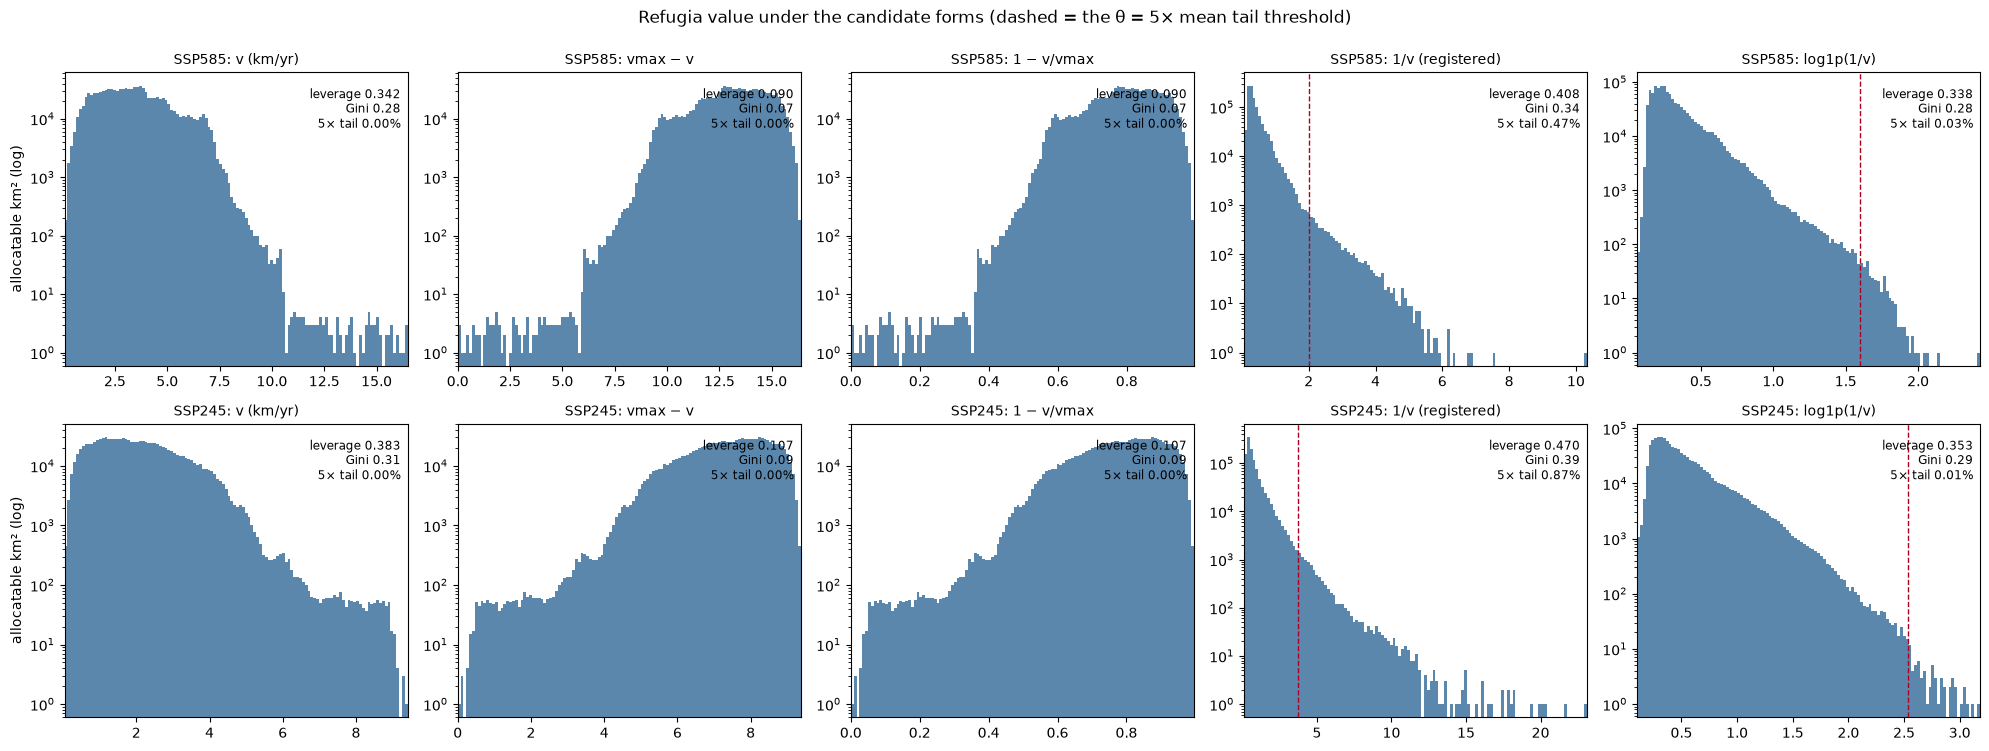

In [3]:
# ---- the distributions (Ethan 2026-09-16): v, vmax - v, 1/v, 1 - v/vmax, and log1p(1/v) on allocatable land, both realizations ----
def forms(v):
    vmax = float(v.max())
    return {"v (km/yr)": v, "vmax − v": vmax - v, "1 − v/vmax": 1.0 - v / vmax, "1/v (registered)": 1.0 / v, "log1p(1/v)": np.log1p(1.0 / v)}
Q = [0, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999, 1.0]
rows = []
for lv in ("585", "245"):
    for name, x in forms(RAW[lv][G.disc]).items():
        qs = np.quantile(x, Q); lo, hi, lev = lc.leverage_of(x)
        rows.append(dict(realization=f"ssp{lv}", form=name, mean=float(x.mean()), gini=float(lc._gini(x)), leverage=lev,
                         theta_tail_area_pct=100 * float((x >= 5 * x.mean()).mean()), **{f"q{int(q * 1000) / 10:g}": float(v) for q, v in zip(Q, qs)}))
DIST = pd.DataFrame(rows); DIST.to_csv(REC / "E20_refugia_distributions.csv", index=False)
print(DIST.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
fig, axes = plt.subplots(2, 5, figsize=(20, 7.5))
for r, lv in enumerate(("585", "245")):
    for ax, (name, x) in zip(axes[r], forms(RAW[lv][G.disc]).items()):
        ax.hist(x, bins=120, color="#5b87ad")
        ax.set_xlim(float(x.min()), float(x.max()))                           # the axis is the data range ...
        if 5 * x.mean() <= x.max(): ax.axvline(5 * x.mean(), color="#b00020", lw=1, ls="--")   # ... the tail line only where a tail can exist
        ax.set_yscale("log"); ax.set_title(f"SSP{lv}: {name}", fontsize=10); ax.set_ylabel("allocatable km² (log)" if ax is axes[r][0] else "")
        lo, hi, lev = lc.leverage_of(x)
        ax.text(0.98, 0.95, f"leverage {lev:.3f}\nGini {lc._gini(x):.2f}\n5× tail {100 * (x >= 5 * x.mean()).mean():.2f}%", transform=ax.transAxes, ha="right", va="top", fontsize=8.5)
fig.suptitle("Refugia value under the candidate forms (dashed = the θ = 5× mean tail threshold)", y=0.995)
fig.tight_layout(); fig.savefig(FIG / "e20_refugia_distributions.png", dpi=150, bbox_inches="tight"); plt.show()


In [4]:
# ---- the test layers (log1p(1/v), both realizations) + the guarded run's weights under constant intended influence ----
LAYER = {}
for lv in ("585", "245"):
    x = np.log1p(1.0 / RAW[lv]).astype(np.float32)
    out = config.HANDOFF_DIR / f"e20_log_refugia_{lv}.tif"
    dc.write_tif(G, x, out, dtype="float32", nodata=np.nan)
    LAYER[lv] = out
    lo, hi, lev = lc.leverage_of(x[G.disc]); print(f"{out.name}: leverage {lev:.3f} (registered 1/v: {lc.leverage_of(STACK[lv][G.disc])[2]:.3f})")
sc = json.loads((SPEC / "scenarios_v2.json").read_text()); S0 = sc["S0_balanced"]
MAN = dc.package_manifest(pd.read_csv(dc.MANIFEST)); row = MAN[MAN.formulation_id == "s0_ssp585_theta5"].iloc[0]
w_reg = json.loads(row.weight_vector); t_full = json.loads(row.target_vector)
def wts(layer_paths=None):
    d = lc.scenario_weights(S0["block_shares"], within_block=S0["within_block"], targets=S0["targets"], layer_paths=layer_paths)
    return {r.feature: round(float(r.w), 6) for r in d.itertuples()}
w_chk = wts(); assert all(abs(w_chk[f] - w_reg[f]) < 1e-5 for f in w_reg), "re-derived S0 weights do not reproduce the manifest row"
w_log = wts(layer_paths={"climate_type_macrorefugia": LAYER["585"]})
print("S0@585 weights, registered vs under log1p(1/v) (constant intended influence):")
for f in w_reg: print(f"   {f:32s} {w_reg[f]:.4f} -> {w_log[f]:.4f}")
payload = dict(created_utc=datetime.now(timezone.utc).isoformat(), spec="study plan v0.18 PF-1 (E20 candidate); methods_log M4.34",
    base_formulation="s0_ssp585_theta5", variant="log1p(1/v)", layer_patch={"climate_type_macrorefugia": str(LAYER["585"].relative_to(ROOT))},
    layer_patch_245={"climate_type_macrorefugia": str(LAYER["245"].relative_to(ROOT))},
    weights=w_log, weights_registered=w_reg, targets=t_full, k=int(row.k_requested), band_g=float(row.band_gap_g), floor_g=0.05, opt_gap=float(row.opt_gap),
    numerics=dict(v_floor_km_per_yr=V_FLOOR, span_yr=SPAN_YR, min_v_on_pu=float(min(RAW[lv].min() for lv in RAW)),
                  floor_inert=bool(min(RAW[lv].min() for lv in RAW) > V_FLOOR)),
    horizon_cap=dict(horizon_yr=HORIZON_YR, span_km=SPAN_KM, cap_yr_per_km=CAP),
    expectations=dict(ordering="real", extreme_tail="partly numerical", saturating_model="shrinks the refugia share of the core materially",
                      durable_core="carbon tail + multi-claim land", alberta="still coreless for honest reasons"))
(REC / "e20_refugia_transform.json").write_text(json.dumps(payload, indent=2))
print(f"wrote {REC / 'e20_refugia_transform.json'} -- next: 18e (R, Ethan: one guarded run, ~1 h) -> 18f")


e20_log_refugia_585.tif: leverage 0.338 (registered 1/v: 0.408)


e20_log_refugia_245.tif: leverage 0.353 (registered 1/v: 0.470)


S0@585 weights, registered vs under log1p(1/v) (constant intended influence):
   climate_type_macrorefugia        1.4600 -> 1.6932
   transboundary_connectivity       0.6693 -> 0.6412
   climate_corridors                1.1714 -> 1.1221
   irrecoverable_carbon_m_soc       0.4646 -> 0.4451
   irrecoverable_carbon_biomass     0.1986 -> 0.1902
   aoh_richness_birds               1.3286 -> 1.2727
   aoh_richness_mammals             1.7075 -> 1.6357
wrote /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/analyses/y2y/spec/v3.1/e20_refugia_transform.json -- next: 18e (R, Ethan: one guarded run, ~1 h) -> 18f


In [5]:
# ---- PF-1 correction: the precision-relative contrast test on the refugia tail ---------------------------------------
# Velocity is a distance (1 km grain) over the 110-yr span, so its precision is dv = 1/110 km/yr and the precision of 1/v at a cell
# is d(1/v) = dv / v^2 (largest for the slowest cells -- exactly the tail). Question: does the separation among tail cells exceed it?
from scipy.stats import spearmanr
rows = []
for lv in ("585", "245"):
    v = RAW[lv][G.disc]; r = 1.0 / v; thr = theta * r.mean(); tail = r >= thr
    dprec = V_FLOOR / v[tail] ** 2                                   # precision of 1/v at each tail cell (yr/km)
    sep = r[tail] - thr                                              # separation from the tail threshold
    other = "245" if lv == "585" else "585"
    r_o = 1.0 / RAW[other][G.disc]; thr_o = theta * r_o.mean()
    rows.append(dict(realization=f"ssp{lv}", tail_cells=int(tail.sum()), tail_threshold=float(thr), tail_max=float(r.max()),
                     median_precision_in_tail=float(np.median(dprec)), precision_at_top=float(dprec[np.argmax(r[tail])]),
                     distinct_levels_in_tail=float((r[tail].max() - thr) / np.median(dprec)),
                     share_of_tail_above_threshold_by_more_than_precision=100 * float((sep > dprec).mean()),
                     share_of_tail_within_precision_of_threshold=100 * float((sep <= dprec).mean()),
                     spearman_tail_vs_other_realization=float(spearmanr(r[tail], r_o[tail]).correlation),
                     share_of_tail_in_other_realizations_tail=100 * float((r_o[tail] >= thr_o).mean()),
                     analog_distance_km_at_threshold=float(SPAN_YR / thr), analog_distance_km_at_top=float(SPAN_YR / r.max())))
PREC = pd.DataFrame(rows); PREC.to_csv(REC / "E20_refugia_precision_contrast.csv", index=False)
print(PREC.T.to_string(float_format=lambda v: f"{v:.3f}"))


                                                           0       1
realization                                           ssp585  ssp245
tail_cells                                              5134    9378
tail_threshold                                         2.007   3.722
tail_max                                              10.328  23.105
median_precision_in_tail                               0.057   0.189
precision_at_top                                       0.970   4.853
distinct_levels_in_tail                              146.939 102.628
share_of_tail_above_threshold_by_more_than_precision  94.235  89.582
share_of_tail_within_precision_of_threshold            5.765  10.418
spearman_tail_vs_other_realization                     0.575   0.211
share_of_tail_in_other_realizations_tail              62.213  34.058
analog_distance_km_at_threshold                       54.808  29.552
analog_distance_km_at_top                             10.651   4.761


In [6]:
# ---- PF-2: the uniform value-shape audit -- every continuous value under its defensible shapes (zero-solve) -------------
# Per feature: the physical quantity, the shapes worth defending, and leverage / class / theta-tail under each candidate.
# Adoption for the ONE guarded run (M4.35): refugia saturating log1p(1/v) + transboundary connectivity convex I^2; climate corridors
# convex ONLY if the Carroll layer is raw/cumulative current (provenance check below); carbon linear (physics); AOH audited, not adopted;
# naturalness audited under 1/gHM and -log(gHM) to demonstrate the principled exclusion (tail below the index's precision).
RAWV = {f: np.nan_to_num(lc._read(config.HANDOFF_DIR / f"{f}.tif")[G.pu], nan=0.0) for f in
        ("transboundary_connectivity", "climate_corridors", "irrecoverable_carbon_m_soc", "irrecoverable_carbon_biomass", "aoh_richness_birds", "aoh_richness_mammals")}
GHM = np.clip(np.nan_to_num(lc._read(ROOT / "input_data" / "cleaned_aligned" / "human_modification.tif")[G.pu], nan=0.0), 0, 1)   # raw gHM (the stack holds 1 - gHM)
STATEMENTS = {
 "climate_type_macrorefugia": ("years per km before the cell's future climate arrives from its nearest present-day source (1/backward velocity)",
                               "linear or SATURATING (persistence beyond the planning horizon adds nothing); convex not defensible"),
 "transboundary_connectivity": ("current density (Pither/O'Brien omnidirectional Circuitscape, raw current)",
                                "CONVEX (I^2 = dissipated power; a pinch point's flow has no alternative path -- loss severs rather than reduces) or linear (never defended)"),
 "climate_corridors": ("Carroll et al. 2018 current-flow centrality between climate-analog pairs",
                       "convex on the same pinch-point logic IF the layer is raw/cumulative current; if a derived (already compressed) index, the shape question belongs to its construction"),
 "irrecoverable_carbon_m_soc": ("tonnes of irrecoverable mineral-soil carbon per hectare", "LINEAR (a tonne is a tonne); dominance handled by the target"),
 "irrecoverable_carbon_biomass": ("tonnes of irrecoverable biomass carbon per hectare", "LINEAR (a tonne is a tonne)"),
 "aoh_richness_birds": ("count of bird species with area of habitat in the cell", "linear or SATURATING (diminishing per-cell value of additional species is arguable) -- the deferred case, reopened"),
 "aoh_richness_mammals": ("count of mammal species with area of habitat in the cell", "linear or SATURATING -- the deferred case, reopened"),
 "human_modification": ("unmodified fraction of the cell (1 - gHM)", "LINEAR bounded complement; any convex form (1/gHM, -log gHM) manufactures a tail below the index's precision -- excluded on principle"),
}
def cands(f):
    if f == "climate_type_macrorefugia":
        r = 1.0 / RAW["585"]
        return {"1/v (registered)": r, "log1p(1/v) [saturating]": np.log1p(r), "sqrt(1/v) [saturating]": np.sqrt(r), "(1/v)^2 [convex]": r ** 2}
    if f == "human_modification":
        out = {"1 - gHM (registered)": 1.0 - GHM}
        for eps in (0.01, 0.001):
            g = np.maximum(GHM, eps)
            out[f"1/max(gHM, {eps}) [convex]"] = 1.0 / g; out[f"-log(max(gHM, {eps})) [convex]"] = -np.log(g)
        return out
    x = RAWV[f]
    return {"identity (registered)": x, "log1p [saturating]": np.log1p(x), "sqrt [saturating]": np.sqrt(x), "square [convex]": x ** 2}
rows = []
for f, (qty, shapes) in STATEMENTS.items():
    for name, x in cands(f).items():
        xd = x[G.disc]; cls, lever, target, d = lc.classify_values(xd, config.AUDIT); m = xd.mean(); tail = xd >= theta * m
        rows.append(dict(feature=f, candidate=name, leverage=d["leverage"], cap_min=d["cap_min"], cap_max=d["cap_max"], cls=cls, lever=lever, target=target,
                         theta_tail_area_pct=100 * float(tail.mean()), theta_tail_mass=float(xd[tail].sum() / xd.sum()) if xd.sum() > 0 else np.nan,
                         gini=float(lc._gini(xd)), passes_R3=bool(d["leverage"] >= config.AUDIT["leverage_min"]),
                         core_in_theta_tail_pct=100 * float((x[core1d] >= theta * m).mean()), physical_quantity=qty, defensible_shapes=shapes))
SHAPE = pd.DataFrame(rows); SHAPE.to_csv(REC / "E20_value_shape_audit.csv", index=False)
print(SHAPE.drop(columns=["physical_quantity", "defensible_shapes"]).to_string(index=False, float_format=lambda v: f"{v:.3f}"))
# provenance check on the Carroll layer: a raw cumulative current is heavy-tailed like Pither's; a compressed index is not
cc, tc = RAWV["climate_corridors"][G.disc], RAWV["transboundary_connectivity"][G.disc]
print(f"\nprovenance evidence -- climate corridors: max/median {cc.max() / np.median(cc):.1f}, 5x tail {100 * (cc >= 5 * cc.mean()).mean():.3f}%, skew {float(pd.Series(cc).skew()):.2f} | "
      f"transboundary (raw current): max/median {tc.max() / np.median(tc):.1f}, 5x tail {100 * (tc >= 5 * tc.mean()).mean():.3f}%, skew {float(pd.Series(tc).skew()):.2f}")


                     feature                      candidate  leverage  cap_min  cap_max                        cls            lever  target  theta_tail_area_pct  theta_tail_mass  gini  passes_R3  core_in_theta_tail_pct
   climate_type_macrorefugia               1/v (registered)     0.408    0.140    0.547             diffuse-linear           weight   1.000                0.475            0.032 0.339       True                  17.586
   climate_type_macrorefugia        log1p(1/v) [saturating]     0.338    0.161    0.499             diffuse-linear           weight   1.000                0.030            0.002 0.277       True                   1.117
   climate_type_macrorefugia         sqrt(1/v) [saturating]     0.201    0.214    0.416             diffuse-linear           weight   1.000                0.000            0.000 0.164       True                   0.003
   climate_type_macrorefugia               (1/v)^2 [convex]     0.758    0.042    0.800     concentrated-satiating          

In [7]:
# ---- PF-2 layers + the consistent-set weights for the second guarded run (18f) ----------------------------------------------
# Carroll layer (M4.35 addendum 3): a sum of per-climate-type passage probabilities (bounded per type, hence tail-less by construction).
# Ethan (2026-09-16): square it for now -- the claim is 'a bottleneck shared by many climate types is worth disproportionately more'.
CORRIDORS_CONVEX = True
conn_sq = (RAWV["transboundary_connectivity"] ** 2).astype(np.float32)
P_CONN = config.HANDOFF_DIR / "e20_conn_sq.tif"; dc.write_tif(G, conn_sq, P_CONN, dtype="float32", nodata=np.nan)
patch = {"climate_type_macrorefugia": LAYER["585"], "transboundary_connectivity": P_CONN}
if CORRIDORS_CONVEX:
    P_CORR = config.HANDOFF_DIR / "e20_corr_sq.tif"; dc.write_tif(G, (RAWV["climate_corridors"] ** 2).astype(np.float32), P_CORR, dtype="float32", nodata=np.nan)
    patch["climate_corridors"] = P_CORR
# R2 would give I^2 connectivity a TARGET at its theta-tail capture (concentrated-satiating; the carbon precedent). Ethan's call
# (2026-09-16): the PF-2 run is the SHAPE change alone at the registered t = 1.0 (the spec's literal "saturating refugia + convex
# connectivity"); the R2-target version is written as an OPTIONAL third arm (e20_consistent_target) for an E10-style comparison.
APPLY_R2_TARGET = False
xd = conn_sq[G.disc]; cls_sq, lever_sq, t_sq, d_sq = lc.classify_values(xd, config.AUDIT)
print(f"transboundary I^2: leverage {d_sq['leverage']:.3f}, class {cls_sq}, lever {lever_sq}, R2 target {t_sq}, theta-tail {100 * float((xd >= theta * xd.mean()).mean()):.3f}% of cells")
def cons_arm(with_target):
    t_c = dict(t_full); t_s = dict(S0["targets"])                          # registered target vector (m_soc + EFG) / the continuous targets in the swing
    if with_target and cls_sq == "concentrated-satiating":
        t_c["transboundary_connectivity"] = float(t_sq); t_s["transboundary_connectivity"] = float(t_sq)
    w = {r.feature: round(float(r.w), 6) for r in lc.scenario_weights(S0["block_shares"], within_block=S0["within_block"], targets=t_s, layer_paths=patch).itertuples()}
    return w, t_c
w_cons, t_cons = cons_arm(APPLY_R2_TARGET)                               # the PF-2 run
w_cons_t, t_cons_t = cons_arm(True)                                       # the optional R2-target arm
print("S0@585 weights under the consistent set (log1p(1/v) refugia + I^2 transboundary" + (" + I^2 corridors" if CORRIDORS_CONVEX else "") + "):")
print(f"   {'feature':32s} {'registered':>10s} {'PF-2 run (t=1)':>15s} {'R2-target arm (t=' + format(t_sq, '.3f') + ')':>26s}")
for f in w_reg: print(f"   {f:32s} {w_reg[f]:10.4f} {w_cons[f]:15.4f} {w_cons_t[f]:26.4f}")
ratio = lambda x: float(np.nanmax(x) / np.nanmean(x))                               # PU vectors; scale-invariant identity check for the R side
CHECK = {"climate_type_macrorefugia": dict(registered=ratio(STACK["585"]), log1p=ratio(np.log1p(1.0 / RAW["585"]))),
         "transboundary_connectivity": dict(registered=ratio(RAWV["transboundary_connectivity"]), square=ratio(conn_sq))}
if CORRIDORS_CONVEX: CHECK["climate_corridors"] = dict(registered=ratio(RAWV["climate_corridors"]), square=ratio(RAWV["climate_corridors"] ** 2))
print("max/mean on the PU (the ingest-invariant check):", json.dumps({k: {kk: round(v, 2) for kk, v in d.items()} for k, d in CHECK.items()}))
payload = json.loads((REC / "e20_refugia_transform.json").read_text())
payload["layer_check"] = {"climate_type_macrorefugia": CHECK["climate_type_macrorefugia"]["log1p"]}      # PF-1 arm: the log layer's max/mean
payload["arms"] = {
    "e20_log": dict(label="PF-1: saturating refugia (log1p(1/v))", layer_patch=payload["layer_patch"], weights=payload["weights"], out_rel="analyses/y2y/runs_v3.1/e20_log"),
    "e20_consistent": dict(label="PF-2: consistent set -- saturating refugia + convex transboundary connectivity (weight only, t = 1)" + (" + convex corridors" if CORRIDORS_CONVEX else ""),
                           layer_patch={k: str(v.relative_to(ROOT)) for k, v in patch.items()}, weights=w_cons, targets=t_cons, out_rel="analyses/y2y/runs_v3.1/e20_consistent",
                           corridors_convex=CORRIDORS_CONVEX, apply_r2_target=APPLY_R2_TARGET, transboundary_class=cls_sq, transboundary_r2_target=float(t_sq),
                           layer_check={"climate_type_macrorefugia": CHECK["climate_type_macrorefugia"]["log1p"], "transboundary_connectivity": CHECK["transboundary_connectivity"]["square"],
                                        **({"climate_corridors": CHECK["climate_corridors"]["square"]} if CORRIDORS_CONVEX else {})},
                           expectations="refugia share of the core falls; pinch points and multi-claim land rise; the core becomes easier to defend"),
    "e20_consistent_target": dict(label="optional: the consistent set WITH R2's connectivity target (t = " + format(t_sq, ".3f") + ")",
                           layer_patch={k: str(v.relative_to(ROOT)) for k, v in patch.items()}, weights=w_cons_t, targets=t_cons_t, out_rel="analyses/y2y/runs_v3.1/e20_consistent_target",
                           corridors_convex=CORRIDORS_CONVEX, apply_r2_target=True, transboundary_class=cls_sq, transboundary_r2_target=float(t_sq),
                           layer_check={"climate_type_macrorefugia": CHECK["climate_type_macrorefugia"]["log1p"], "transboundary_connectivity": CHECK["transboundary_connectivity"]["square"],
                                        **({"climate_corridors": CHECK["climate_corridors"]["square"]} if CORRIDORS_CONVEX else {})},
                           optional=True),
}
(REC / "e20_refugia_transform.json").write_text(json.dumps(payload, indent=2))
print("arms written to e20_refugia_transform.json -- 18e runs e20_log, 18f runs e20_consistent, 18g reads whichever exist")


transboundary I^2: leverage 0.719, class concentrated-satiating, lever target, R2 target 0.198, theta-tail 2.020% of cells


S0@585 weights under the consistent set (log1p(1/v) refugia + I^2 transboundary + I^2 corridors):
   feature                          registered  PF-2 run (t=1)    R2-target arm (t=0.198)
   climate_type_macrorefugia            1.4600          1.8802                     1.8995
   transboundary_connectivity           0.6693          0.4484                     0.3811
   climate_corridors                    1.1714          0.7363                     0.7439
   irrecoverable_carbon_m_soc           0.4646          0.4943                     0.4993
   irrecoverable_carbon_biomass         0.1986          0.2112                     0.2134
   aoh_richness_birds                   1.3286          1.4133                     1.4278
   aoh_richness_mammals                 1.7075          1.8163                     1.8350
max/mean on the PU (the ingest-invariant check): {"climate_type_macrorefugia": {"registered": 24.47, "log1p": 7.31}, "transboundary_connectivity": {"registered": 40.23, "square": 105

/var/folders/9r/qvrv12td3y9_rcssqr2csvbm0000gn/T/ipykernel_42034/2781316777.py:10: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout(); fig.savefig(FIG / "e20_refugia_audit.png", dpi=160, bbox_inches="tight"); plt.show()


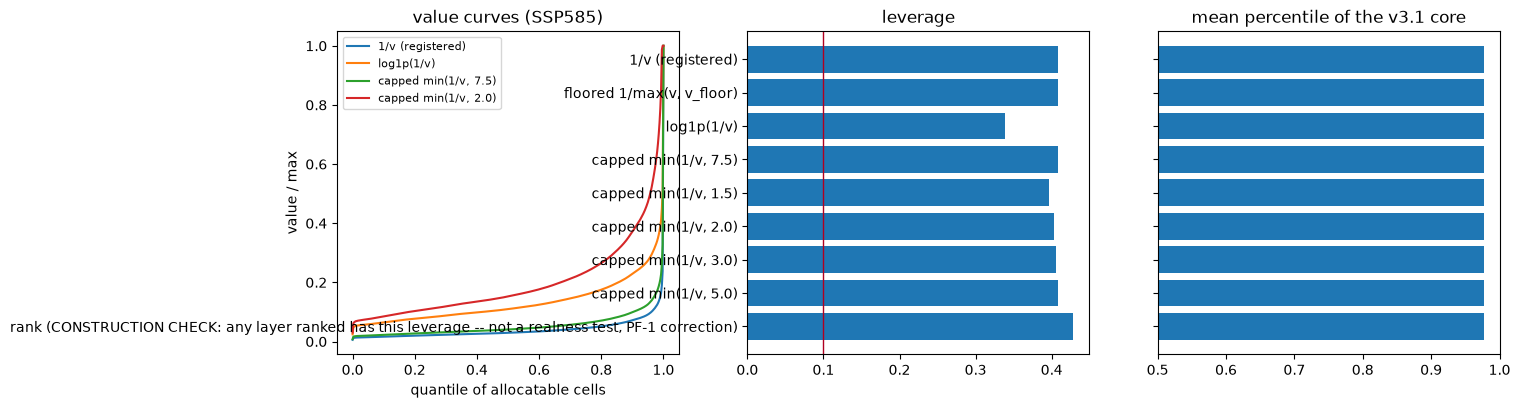

In [8]:
# ---- figure: the value curves + where the core sits (SSP585) --------------------------------------------------------
V = variants(RAW["585"]); fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
q = np.linspace(0, 1, 401)
for name in ["1/v (registered)", "log1p(1/v)", f"capped min(1/v, {CAP:.1f})", "capped min(1/v, 2.0)"]:
    x = V[name][G.disc]; xs = np.quantile(x, q); axes[0].plot(q, xs / xs.max(), label=name)
axes[0].set_xlabel("quantile of allocatable cells"); axes[0].set_ylabel("value / max"); axes[0].set_title("value curves (SSP585)"); axes[0].legend(fontsize=8)
a = AUD[AUD.realization == "ssp585"].set_index("variant")
axes[1].barh(a.index, a.leverage); axes[1].axvline(config.AUDIT["leverage_min"], color="#b00020", lw=1); axes[1].set_title("leverage"); axes[1].invert_yaxis()
axes[2].barh(a.index, a.core_mean_percentile); axes[2].set_xlim(0.5, 1.0); axes[2].set_title("mean percentile of the v3.1 core"); axes[2].invert_yaxis(); axes[2].set_yticklabels([])
fig.tight_layout(); fig.savefig(FIG / "e20_refugia_audit.png", dpi=160, bbox_inches="tight"); plt.show()


In [9]:
# ---- STEP 1 output: the one table (shapes x features x leverage / tail area / implied target / class) ------------------------
T1 = SHAPE[["feature", "candidate", "leverage", "theta_tail_area_pct", "target", "cls", "passes_R3"]].rename(columns={"candidate": "shape", "theta_tail_area_pct": "tail_area_pct", "target": "implied_target", "cls": "class"})
# the refugia numerics rows (floored / horizon-capped) from the PF-1 audit, SSP585, in the same columns
for _, r in AUD[(AUD.realization == "ssp585") & AUD.variant.str.startswith(("floored", "capped min(1/v, 7.5"))].iterrows():
    T1 = pd.concat([T1, pd.DataFrame([dict(feature="climate_type_macrorefugia", shape=r.variant, leverage=r.leverage, tail_area_pct=r.theta_tail_area_pct,
                                             implied_target=np.nan, **{"class": r.cls}, passes_R3=r.leverage >= config.AUDIT["leverage_min"])])], ignore_index=True)
T1.to_csv(REC / "E20_shape_audit_table.csv", index=False)
print("STEP 1 table -> spec/v3.1/E20_shape_audit_table.csv"); print(T1.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

# ---- STEP 3 (PF-3): block-split arms on the step-2 shapes -- pre-registered in M4.36 ------------------------------------------
# (A) five discretionary blocks at 20%: transboundary and corridors as separate blocks; (B) corridors REMOVED, transboundary alone at
# the connectivity block's 25%. Each on the balanced (S0) and connectivity-forward (S2) profiles = four guarded runs. S2's registered
# profile puts 0.5 on the connectivity theme and 1/6 on each other block; under (A) that 0.5 is split evenly across the two blocks.
S2 = sc["S2_connectivity"]; C6 = 1.0 / 6.0
BLK_A = {"core_habitat": ["climate_type_macrorefugia"], "transboundary": ["transboundary_connectivity"], "corridors": ["climate_corridors"],
         "carbon": ["irrecoverable_carbon_m_soc", "irrecoverable_carbon_biomass"], "biodiversity": ["aoh_richness_birds", "aoh_richness_mammals"]}
BLK_B = {"core_habitat": ["climate_type_macrorefugia"], "connectivity": ["transboundary_connectivity"],
         "carbon": ["irrecoverable_carbon_m_soc", "irrecoverable_carbon_biomass"], "biodiversity": ["aoh_richness_birds", "aoh_richness_mammals"]}
PF3 = {
    "e20_pf3_A_s0": dict(variant="A", scenario="s0", blocks=BLK_A, shares={"core_habitat": 0.2, "transboundary": 0.2, "corridors": 0.2, "carbon": 0.2, "biodiversity": 0.2}),
    "e20_pf3_A_s2": dict(variant="A", scenario="s2", blocks=BLK_A, shares={"core_habitat": C6, "transboundary": 0.25, "corridors": 0.25, "carbon": C6, "biodiversity": C6}),
    "e20_pf3_B_s0": dict(variant="B", scenario="s0", blocks=BLK_B, shares={"core_habitat": 0.25, "connectivity": 0.25, "carbon": 0.25, "biodiversity": 0.25}),
    "e20_pf3_B_s2": dict(variant="B", scenario="s2", blocks=BLK_B, shares={"core_habitat": C6, "connectivity": 0.5, "carbon": C6, "biodiversity": C6}),
}
payload = json.loads((REC / "e20_refugia_transform.json").read_text())
base_arm = payload["arms"]["e20_consistent"]
for name, a in PF3.items():
    d = lc.scenario_weights(a["shares"], within_block={"carbon": S0["within_block"]["carbon"]}, targets=S0["targets"], layer_paths=patch, blocks=a["blocks"])
    w = {r.feature: round(float(r.w), 6) for r in d.itertuples()}
    if a["variant"] == "B": w["climate_corridors"] = 0.0                      # removed from the objective (and from the floors)
    payload["arms"][name] = dict(label=f"PF-3 {a['variant']} @ {a['scenario'].upper()}: " + ("five blocks at 20% (transboundary, corridors separate)" if a["variant"] == "A" else "corridors removed, transboundary alone at the connectivity block's share")
                                       + f" -- shares {json.dumps({k: round(v, 3) for k, v in a['shares'].items()})}",
                                 pf3=True, variant=a["variant"], scenario=a["scenario"], blocks=a["blocks"], block_shares=a["shares"],
                                 layer_patch=base_arm["layer_patch"], layer_check=base_arm["layer_check"], weights=w, targets=t_cons,
                                 out_rel=f"analyses/y2y/runs_v3.1/{name}", requires="analyses/y2y/runs_v3.1/e20_consistent/s0_ssp585_theta5/mga_guard_g05.tif",
                                 reference_registered=f"analyses/y2y/runs_v3.1/{a['scenario']}_ssp585_theta5")
    print(f"{name}: " + ", ".join(f"{f.split('_')[-1] if 'carbon' in f else f.replace('climate_type_','').replace('aoh_richness_','').replace('transboundary_connectivity','transb').replace('climate_corridors','corr')} {v:.3f}" for f, v in w.items()))
(REC / "e20_refugia_transform.json").write_text(json.dumps(payload, indent=2))
print("PF-3 arms written (gated on the step-2 baseline e20_consistent) -- 18f runs them after the consistent arms; 18g compares each to the baseline")


STEP 1 table -> spec/v3.1/E20_shape_audit_table.csv
                     feature                          shape  leverage  tail_area_pct  implied_target                      class  passes_R3
   climate_type_macrorefugia               1/v (registered)     0.408          0.475           1.000             diffuse-linear       True
   climate_type_macrorefugia        log1p(1/v) [saturating]     0.338          0.030           1.000             diffuse-linear       True
   climate_type_macrorefugia         sqrt(1/v) [saturating]     0.201          0.000           1.000             diffuse-linear       True
   climate_type_macrorefugia               (1/v)^2 [convex]     0.758          3.028           0.343     concentrated-satiating       True
  transboundary_connectivity          identity (registered)     0.441          0.173           1.000             diffuse-linear       True
  transboundary_connectivity             log1p [saturating]     0.307          0.000           1.000             d

e20_pf3_A_s0: macrorefugia 1.608, transb 0.767, corr 1.260, soc 0.423, biomass 0.181, birds 1.209, mammals 1.553


e20_pf3_A_s2: macrorefugia 1.405, transb 1.005, corr 1.650, soc 0.369, biomass 0.158, birds 1.056, mammals 1.357


e20_pf3_B_s0: macrorefugia 1.681, transb 0.802, soc 0.442, biomass 0.189, birds 1.263, mammals 1.624, corr 0.000


e20_pf3_B_s2: macrorefugia 1.326, transb 1.898, soc 0.349, biomass 0.149, birds 0.997, mammals 1.281, corr 0.000
PF-3 arms written (gated on the step-2 baseline e20_consistent) -- 18f runs them after the consistent arms; 18g compares each to the baseline
